# Word Sense Disambiguation (SemEval-2026 Task 5) - Group 02 Final Submission

In this final project submission, we present our complete machine learning pipeline for SemEval-2026 Task 5. Our goal is to predict continuous plausibility ratings for ambiguous word senses within short narrative contexts.

Through extensive experimentation, we identified that our best performing approach utilizes a flat **DeBERTa-v3-base** architecture combined with a **Multi-Objective Loss Function** (Huber, RankNet, and Uncertainty-Aware Margin). This effectively balances predictive accuracy with relative ranking (Spearman correlation). Additionally, we implement post-training **Nelder-Mead Threshold Optimization** to maximize our discrete Macro F1 score classification.

## Step 1: Environment Setup and Seed Initialization

First, we install our necessary dependencies and meticulously set up a global random seed. Setting a deterministic seed across Python, NumPy, and PyTorch ensures that our results are perfectly reproducible for evaluation.


In [1]:
!pip install transformers scikit-learn pandas scipy


In [2]:
import json
import copy
import warnings
import os
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Any

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.optimize import minimize
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def set_seed(seed=42):
    """Sets the seed for entire pipeline for reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Ensure deterministic behavior in PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


Device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Then update data_dir path in run_training():
# data_dir = Path("/content/drive/My Drive/CS 445 final project/data")

Mounted at /content/drive


## Step 2: Data Loading and Flat Concatenation

Our dataset consists of 5-sentence stories where the last sentence can retroactively change the meaning of the preceding sentences. To allow our model to cross-attend between all parts of the narrative simultaneously, we concatenate the precontext, sentence, ending, and target meaning into a single string separated by `[SEP]` tokens.

We construct our custom PyTorch `Dataset` and `DataLoader` classes to handle this process. The data is parsed correctly from dictionaries into lists to prevent indexing errors during batching.


In [4]:
MODEL_NAME = "microsoft/deberta-v3-base"

def build_tokenizer():
    return AutoTokenizer.from_pretrained(MODEL_NAME)

class AmbiStoryDataset(Dataset):
    def __init__(self, path):
        with Path(path).open("r", encoding="utf-8") as f:
            raw = json.load(f)

        # Parse from dictionary to list properly
        items = sorted(raw.items(), key=lambda x: int(x[0])) if isinstance(raw, dict) else [(str(i), s) for i, s in enumerate(raw)]

        self.records = []
        for sid, s in items:
            self.records.append({
                "precontext": str(s["precontext"]), "sentence": str(s["sentence"]),
                "ending": "" if s["ending"] is None else str(s["ending"]),
                "meaning": str(s["judged_meaning"]),
                "target_score": float(s["average"]), "target_stdev": float(s["stdev"]),
            })

    def __len__(self): return len(self.records)
    def __getitem__(self, i): return self.records[i]

@dataclass
class Collator:
    tokenizer: Any
    def __call__(self, examples):
        sep = self.tokenizer.sep_token or "[SEP]"

        # Flat concatenation of narrative components
        texts = [f"{e['precontext']} {sep} {e['sentence']} {sep} {e['ending']} {sep} {e['meaning']}" for e in examples]
        enc = self.tokenizer(texts, padding="longest", truncation=True, max_length=512, return_tensors="pt")

        return {
            "input_ids": enc["input_ids"].long(),
            "attention_mask": enc["attention_mask"].long(),
            "target_score": torch.tensor([e["target_score"] for e in examples], dtype=torch.float32),
            "target_stdev": torch.tensor([e["target_stdev"] for e in examples], dtype=torch.float32),
        }

def build_loaders(tokenizer, data_dir, batch_size=32):
    collator = Collator(tokenizer)
    train = DataLoader(AmbiStoryDataset(data_dir / "train.json"), batch_size=batch_size, shuffle=True, collate_fn=collator)
    dev = DataLoader(AmbiStoryDataset(data_dir / "dev.json"), batch_size=batch_size, shuffle=False, collate_fn=collator)
    return train, dev


We choose a batch size of 32 to give our RankNet loss function enough sample pairs to compare in each batch, which is crucial for learning relative rankings.

## Step 3: Model Architecture

We use `microsoft/deberta-v3-base` as our foundation model. Through prior iterations, we discovered that fully fine-tuning a base model yields much better results than using parameter-efficient fine-tuning on a larger model.

We extract the `[CLS]` token embedding, which acts as a summary of the entire concatenated narrative, and pass it through a custom regression head with Dropout. Importantly, we do NOT clamp the outputs using sigmoids, allowing the regression head to output raw continuous scores natively.


In [5]:
class WSDModel(nn.Module):
    def __init__(self):
        super().__init__()
        print(f"Loading {MODEL_NAME}...")
        self.encoder = AutoModel.from_pretrained(MODEL_NAME).float()
        hidden = self.encoder.config.hidden_size
        print(f"Encoder: {sum(p.numel() for p in self.encoder.parameters()):,} params, hidden={hidden}")

        # Raw linear regression head with 10% dropout
        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 1)
        )

    def forward(self, batch):
        out = self.encoder(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])

        # [CLS] token pooling
        cls = out.last_hidden_state[:, 0, :]
        return self.head(cls).squeeze(-1)


## Step 4: Multi-Objective Loss and Evaluation Metrics

Because our task involves both continuous plausibility and discrete classes, standard Mean Squared Error is insufficient. We design a `MultiObjectiveLoss` that computes:
1. **Huber Loss** for robustness against outliers.
2. **RankNet Loss** to optimize the pairwise ranking and drastically improve Spearman correlation.
3. **Uncertainty-Aware Margin** to penalize errors more heavily when human annotators were highly confident.

We also establish our lenient `Accuracy@std` calculation logic and basic evaluation pipelines here.


In [6]:
class RankNetLoss(nn.Module):
    def __init__(self, margin=0.0):
        super().__init__()
        self.margin = margin

    def forward(self, preds, tgts):
        p, t = preds.view(-1), tgts.view(-1)
        mask = (t.unsqueeze(1) - t.unsqueeze(0)) > self.margin
        if not mask.any(): return (p * 0.0).sum()
        return F.softplus(-(p.unsqueeze(1) - p.unsqueeze(0)))[mask].mean()

class UncertaintyLoss(nn.Module):
    def forward(self, preds, tgts, stds):
        return F.relu((preds.view(-1) - tgts.view(-1)).abs() - stds.view(-1).clamp(min=0)).mean()

class MultiObjectiveLoss(nn.Module):
    def __init__(self, lh=1.0, lr=0.5, lu=0.5):
        super().__init__()
        self.lh, self.lr, self.lu = lh, lr, lu
        self.huber = nn.HuberLoss(delta=1.0)
        self.rank = RankNetLoss()
        self.unc = UncertaintyLoss()

    def forward(self, preds, tgts, stds):
        h = self.huber(preds, tgts)
        r = self.rank(preds, tgts)
        u = self.unc(preds, tgts, stds)
        return {"loss": self.lh*h + self.lr*r + self.lu*u, "huber": h, "rank": r, "unc": u}

def clip_and_round(p):
    return np.clip(np.rint(np.asarray(p)), 1, 5).astype(int)

def evaluate_predictions(yt, yp, ys):
    yt, yp, ys = np.asarray(yt), np.clip(np.asarray(yp), 1, 5), np.asarray(ys)

    # Accuracy at standard deviation logic
    acc = np.mean(((yt - ys < yp) & (yp < yt + ys)) | (np.abs(yt - yp) < 1))

    sp, _ = spearmanr(yt, yp); sp = 0.0 if np.isnan(sp) else sp
    f1 = f1_score(clip_and_round(yt), clip_and_round(yp), average="macro", zero_division=0)

    return {"acc_std": acc, "spearman": sp, "f1": f1}

def plot_cm(yt, yp, normalize=True):
    labels = [1,2,3,4,5]
    cm = confusion_matrix(clip_and_round(yt), clip_and_round(yp), labels=labels)
    if normalize: cm = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True)).round(2)
    fig, ax = plt.subplots(figsize=(6,5))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues")
    plt.title("Confusion Matrix (Row-Normalized)" if normalize else "Confusion Matrix")
    plt.show()


## Step 5: Training Loop

We configure the model to run for a maximum of 15 epochs, but we introduce an early stopping mechanism with a patience of 3 to halt training if our validation Spearman score stops improving.

We use differential learning rates: `2e-5` for the DeBERTa encoder to preserve its pre-trained knowledge, and `1e-3` for our randomly initialized regression head.


In [9]:
def run_training(
    batch_size=32,
    enc_lr=2e-5,
    head_lr=5e-4,
    weight_decay=0.1,
    loss_weights=None,  # {"huber": 1.0, "ranknet": 0.5, "uncertainty": 0.5}
    dropout=0.25,
    head_hidden=256,
    huber_delta=1.0,
    ranknet_margin=0.0,
    max_epochs=20,
    patience=5,
    warmup_ratio=0.1,
    verbose=True
):
    """
    Parameterized training function for hyperparameter search.

    Args:
        batch_size: Training batch size
        enc_lr: Learning rate for encoder (DeBERTa)
        head_lr: Learning rate for regression head
        weight_decay: L2 regularization weight
        loss_weights: Dict with keys 'huber', 'ranknet', 'uncertainty'
        dropout: Dropout rate in regression head
        head_hidden: Hidden dimension of regression head
        huber_delta: Delta parameter for HuberLoss
        ranknet_margin: Margin for RankNet loss
        max_epochs: Maximum training epochs
        patience: Early stopping patience
        warmup_ratio: Fraction of steps for warmup
        verbose: Print training progress
    """
    if loss_weights is None:
        loss_weights = {"huber": 1.0, "ranknet": 0.5, "uncertainty": 0.5}

    print(f"Device: {device}")
    tokenizer = build_tokenizer()
    data_dir = Path("/content/drive/My Drive/CS 445 final project/data")
    train_loader, dev_loader = build_loaders(tokenizer, data_dir, batch_size=batch_size)

    # Create model with parameterized dropout
    model = WSDModel().to(device)
    # Replace head with parameterized architecture
    hidden = model.encoder.config.hidden_size
    model.head = nn.Sequential(
        nn.Linear(hidden, head_hidden),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(head_hidden, 1)
    ).to(device)

    enc_p = list(model.encoder.parameters())
    head_p = list(model.head.parameters())
    trainable = enc_p + head_p

    optimizer = optim.AdamW([
        {"params": enc_p, "lr": enc_lr},
        {"params": head_p, "lr": head_lr},
    ], weight_decay=weight_decay)

    criterion = MultiObjectiveLoss(
        lh=loss_weights["huber"],
        lr=loss_weights["ranknet"],
        lu=loss_weights["uncertainty"]
    )
    # Update RankNet margin
    criterion.rank.margin = ranknet_margin

    epochs = max_epochs
    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    best_sp, best_state = -1, None
    no_improve = 0
    best_t, best_p, best_s = None, None, None

    # Tracking dictionaries for visualization
    train_losses = []
    val_losses = []
    spearman_scores = []
    huber_losses = []
    ranknet_losses = []
    uncertainty_losses = []
    val_huber_losses = []
    val_ranknet_losses = []
    val_uncertainty_losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        tloss, nb_ = 0.0, 0
        t_huber, t_ranknet, t_unc = 0.0, 0.0, 0.0

        for step, batch in enumerate(train_loader, 1):
            tgt = batch["target_score"].to(device)
            std = batch["target_stdev"].to(device)
            bd = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
            optimizer.zero_grad()

            pred = model(bd)
            ld = criterion(pred, tgt, std)
            ld["loss"].backward()

            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step(); scheduler.step()
            tloss += ld["loss"].item()
            t_huber += ld["huber"].item()
            t_ranknet += ld["rank"].item()
            t_unc += ld["unc"].item()
            nb_ += 1
            if verbose and step % 20 == 0:
                print(f"  Epoch {epoch} | step {step:>3}/{len(train_loader)} | loss={tloss/nb_:.4f}")

        avg_train_loss = tloss / max(nb_, 1)
        avg_train_huber = t_huber / max(nb_, 1)
        avg_train_ranknet = t_ranknet / max(nb_, 1)
        avg_train_unc = t_unc / max(nb_, 1)

        model.eval()
        all_t, all_p, all_s = [], [], []
        vloss, nb_v = 0.0, 0
        v_huber, v_ranknet, v_unc = 0.0, 0.0, 0.0

        with torch.no_grad():
            for batch in dev_loader:
                tgt = batch["target_score"].to(device)
                std = batch["target_stdev"].to(device)
                bd = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
                p = model(bd)

                # Calculate validation loss
                ld = criterion(p, tgt, std)
                vloss += ld["loss"].item()
                v_huber += ld["huber"].item()
                v_ranknet += ld["rank"].item()
                v_unc += ld["unc"].item()
                nb_v += 1

                all_t.extend(batch["target_score"].numpy())
                all_p.extend(p.cpu().numpy())
                all_s.extend(batch["target_stdev"].numpy())

        m = evaluate_predictions(all_t, all_p, all_s)

        avg_val_loss = vloss / max(nb_v, 1)
        avg_val_huber = v_huber / max(nb_v, 1)
        avg_val_ranknet = v_ranknet / max(nb_v, 1)
        avg_val_unc = v_unc / max(nb_v, 1)

        # Store metrics for visualization
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        spearman_scores.append(m["spearman"])
        huber_losses.append(avg_train_huber)
        ranknet_losses.append(avg_train_ranknet)
        uncertainty_losses.append(avg_train_unc)
        val_huber_losses.append(avg_val_huber)
        val_ranknet_losses.append(avg_val_ranknet)
        val_uncertainty_losses.append(avg_val_unc)

        if verbose:
            print(f"\n  Epoch {epoch}/{epochs} -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc={m['acc_std']:.4f} Spear={m['spearman']:.4f} F1={m['f1']:.4f}")

        if m["spearman"] > best_sp:
            best_sp = m["spearman"]
            best_state = copy.deepcopy(model.state_dict())
            best_t, best_p, best_s = all_t, all_p, all_s
            no_improve = 0
            if verbose:
                print(f"  >> New best Spearman: {best_sp:.4f} (saved)")
        else:
            no_improve += 1
            if verbose:
                print(f"  >> No improvement ({no_improve}/{patience})")
            if no_improve >= patience:
                if verbose:
                    print(f"\nEarly stopping at epoch {epoch}.")
                break
        if verbose:
            print()

    if best_state:
        model.load_state_dict(best_state)
        if verbose:
            print(f"Restored best model (Spearman: {best_sp:.4f})")

    if verbose:
        print("\nTraining Complete.")

    # Return metrics for visualization
    metrics = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "spearman_scores": spearman_scores,
        "huber_losses": huber_losses,
        "ranknet_losses": ranknet_losses,
        "uncertainty_losses": uncertainty_losses,
        "val_huber_losses": val_huber_losses,
        "val_ranknet_losses": val_ranknet_losses,
        "val_uncertainty_losses": val_uncertainty_losses,
    }

    return model, dev_loader, metrics, best_sp, m

# Run with default parameters for quick test
model, dev_loader, metrics = run_training()[:3]

Device: cuda
Loading microsoft/deberta-v3-base...


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Encoder: 183,831,552 params, hidden=768
  Epoch 1 | step  20/72 | loss=3.8507
  Epoch 1 | step  40/72 | loss=2.7969
  Epoch 1 | step  60/72 | loss=2.2737

  Epoch 1/20 -> Train Loss: 2.1013 | Val Loss: 1.1817 | Acc=0.5680 Spear=0.0817 F1=0.0829
  >> New best Spearman: 0.0817 (saved)

  Epoch 2 | step  20/72 | loss=1.2424
  Epoch 2 | step  40/72 | loss=1.2063
  Epoch 2 | step  60/72 | loss=1.2328

  Epoch 2/20 -> Train Loss: 1.2091 | Val Loss: 1.1518 | Acc=0.6344 Spear=0.3463 F1=0.1774
  >> New best Spearman: 0.3463 (saved)

  Epoch 3 | step  20/72 | loss=0.9105
  Epoch 3 | step  40/72 | loss=0.9120
  Epoch 3 | step  60/72 | loss=0.9136

  Epoch 3/20 -> Train Loss: 0.9204 | Val Loss: 0.9670 | Acc=0.6973 Spear=0.4701 F1=0.2404
  >> New best Spearman: 0.4701 (saved)

  Epoch 4 | step  20/72 | loss=0.6392
  Epoch 4 | step  40/72 | loss=0.6678
  Epoch 4 | step  60/72 | loss=0.6592

  Epoch 4/20 -> Train Loss: 0.6566 | Val Loss: 1.0617 | Acc=0.6769 Spear=0.4673 F1=0.2555
  >> No improvement 

## Training Dynamics Visualization

Visualize the evolution of loss components and validation metrics across epochs to understand model convergence behavior.


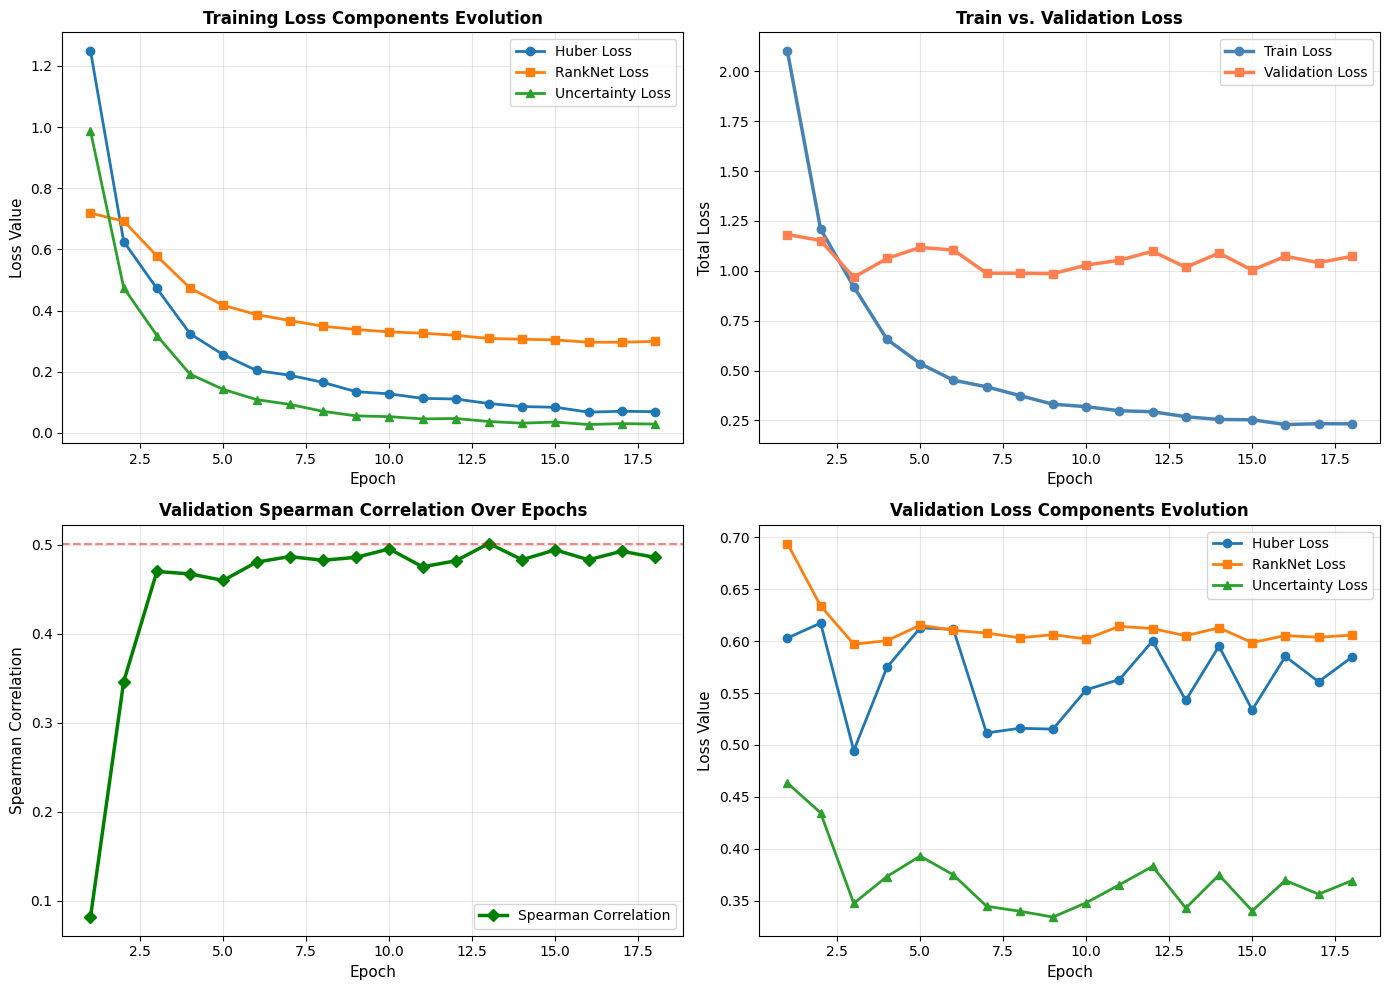

✓ Training dynamics visualized successfully


In [10]:
# Plot training dynamics
epochs_range = range(1, len(metrics["train_losses"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss Component Evolution (Training)
ax = axes[0, 0]
ax.plot(epochs_range, metrics["huber_losses"], label="Huber Loss", marker='o', linewidth=2)
ax.plot(epochs_range, metrics["ranknet_losses"], label="RankNet Loss", marker='s', linewidth=2)
ax.plot(epochs_range, metrics["uncertainty_losses"], label="Uncertainty Loss", marker='^', linewidth=2)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Loss Value", fontsize=11)
ax.set_title("Training Loss Components Evolution", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Total Loss Comparison
ax = axes[0, 1]
ax.plot(epochs_range, metrics["train_losses"], label="Train Loss", marker='o', linewidth=2.5, color='steelblue')
ax.plot(epochs_range, metrics["val_losses"], label="Validation Loss", marker='s', linewidth=2.5, color='coral')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Total Loss", fontsize=11)
ax.set_title("Train vs. Validation Loss", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Spearman Correlation Evolution
ax = axes[1, 0]
ax.plot(epochs_range, metrics["spearman_scores"], label="Spearman Correlation", marker='D', linewidth=2.5, color='green')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Spearman Correlation", fontsize=11)
ax.set_title("Validation Spearman Correlation Over Epochs", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(y=max(metrics["spearman_scores"]), color='red', linestyle='--', alpha=0.5, label=f'Best: {max(metrics["spearman_scores"]):.4f}')

# Validation Loss Components
ax = axes[1, 1]
ax.plot(epochs_range, metrics["val_huber_losses"], label="Huber Loss", marker='o', linewidth=2)
ax.plot(epochs_range, metrics["val_ranknet_losses"], label="RankNet Loss", marker='s', linewidth=2)
ax.plot(epochs_range, metrics["val_uncertainty_losses"], label="Uncertainty Loss", marker='^', linewidth=2)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Loss Value", fontsize=11)
ax.set_title("Validation Loss Components Evolution", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training dynamics visualized successfully")


## Baseline Model Analysis

Analyze the performance of the baseline model (default parameters) on validation data before hyperparameter tuning.

BASELINE MODEL VALIDATION PERFORMANCE

Spearman Correlation: 0.5015
Accuracy@std: 0.6956
Macro F1 Score: 0.3086

Mean Absolute Error (MAE): 0.9320
Median Absolute Error: 0.8055
Root Mean Squared Error (RMSE): 1.1675


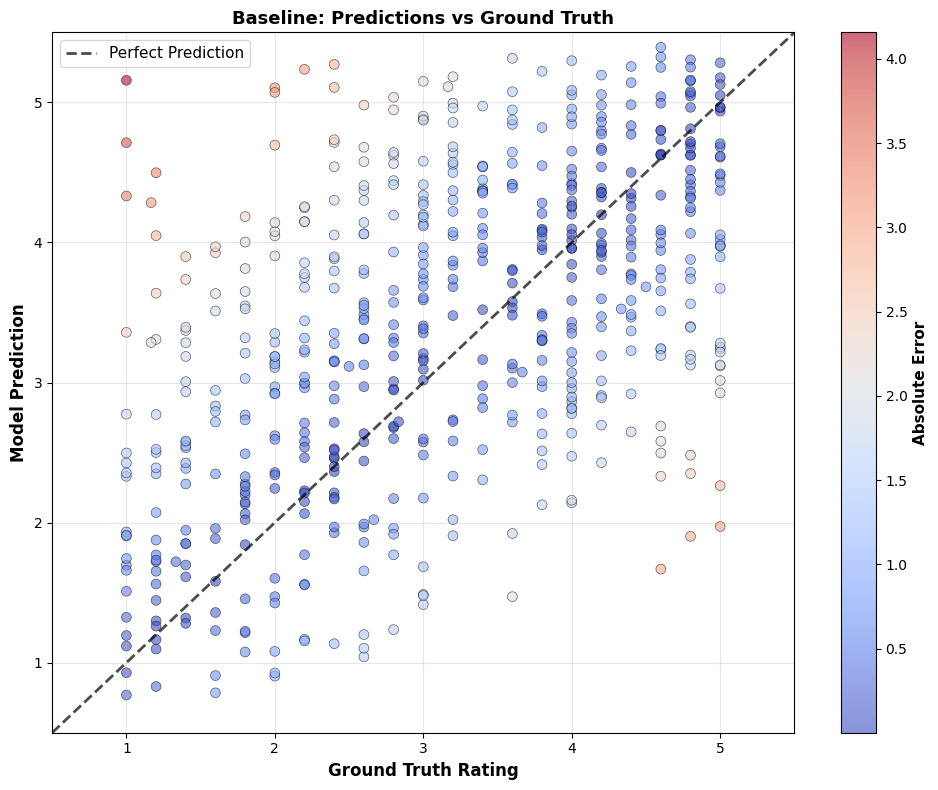

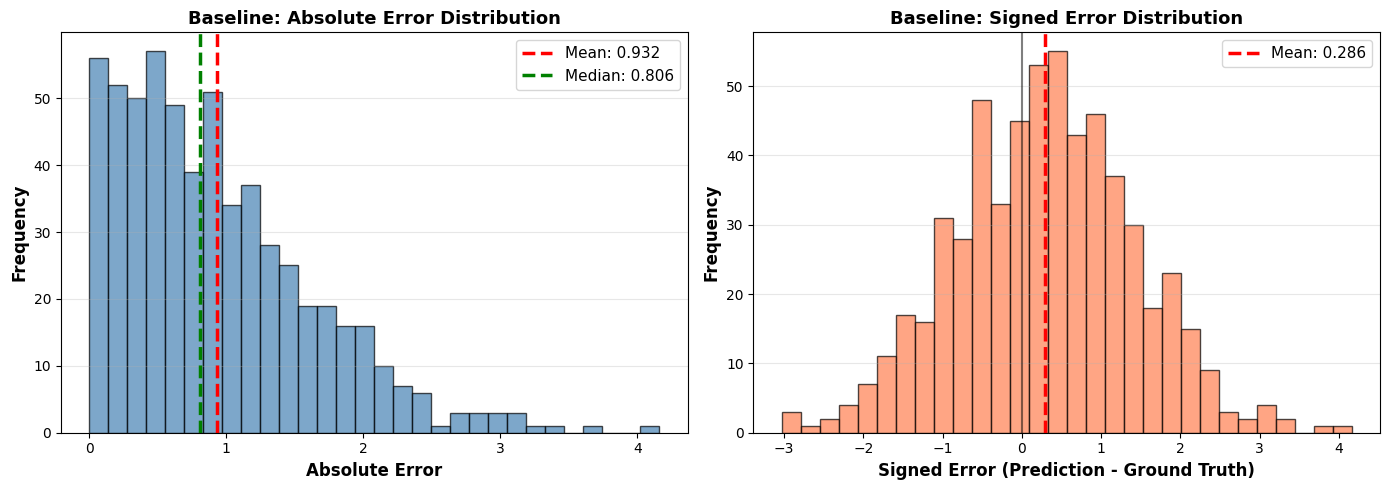

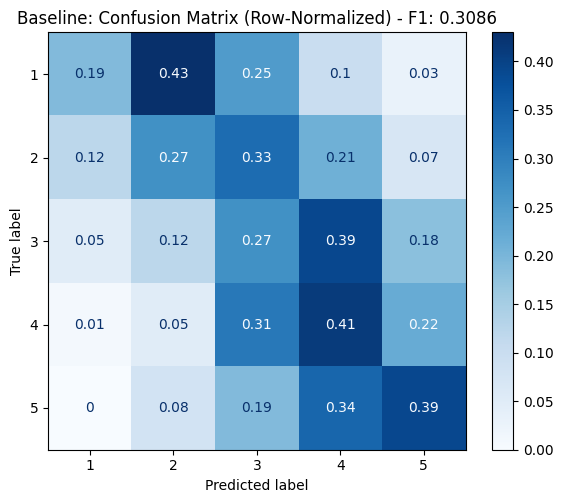

/tmp/ipykernel_1313/1846860961.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(error_by_class, labels=['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5'],
/tmp/ipykernel_1313/1846860961.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(abs_error_by_class, labels=['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5'],


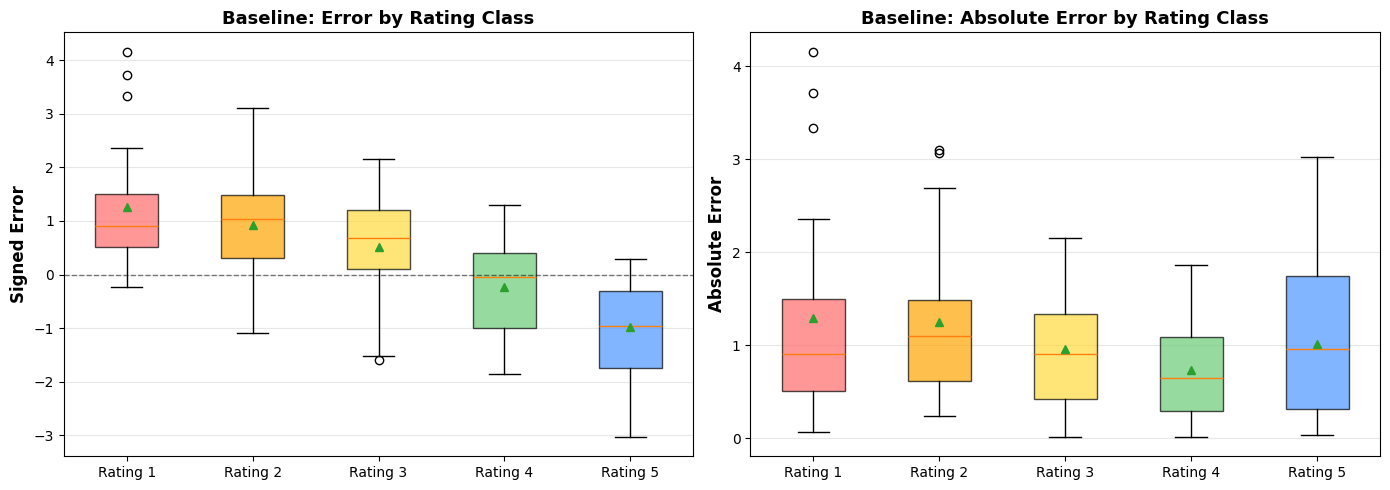


✓ Baseline model analysis complete


In [14]:
# Collect baseline model predictions
model.eval()
baseline_preds, baseline_trues, baseline_stds = [], [], []
with torch.no_grad():
    for batch in dev_loader:
        bd = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        p = model(bd)
        baseline_preds.extend(p.cpu().numpy())
        baseline_trues.extend(batch["target_score"].numpy())
        baseline_stds.extend(batch["target_stdev"].numpy())

baseline_preds = np.array(baseline_preds)
baseline_trues = np.array(baseline_trues)
baseline_stds = np.array(baseline_stds)

# Calculate baseline metrics
baseline_metrics = evaluate_predictions(baseline_trues, baseline_preds, baseline_stds)

print("=" * 70)
print("BASELINE MODEL VALIDATION PERFORMANCE")
print("=" * 70)
print(f"\nSpearman Correlation: {baseline_metrics['spearman']:.4f}")
print(f"Accuracy@std: {baseline_metrics['acc_std']:.4f}")
print(f"Macro F1 Score: {baseline_metrics['f1']:.4f}")

baseline_errors = baseline_preds - baseline_trues
baseline_abs_errors = np.abs(baseline_errors)
print(f"\nMean Absolute Error (MAE): {np.mean(baseline_abs_errors):.4f}")
print(f"Median Absolute Error: {np.median(baseline_abs_errors):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(np.mean(baseline_errors**2)):.4f}")
print("=" * 70)

# 1. Predictions vs Ground Truth (Baseline)
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(baseline_trues, baseline_preds, alpha=0.6, s=50,
                    c=np.abs(baseline_preds - baseline_trues), cmap='coolwarm',
                    edgecolors='black', linewidth=0.5)
ax.plot([0.5, 5.5], [0.5, 5.5], 'k--', linewidth=2, label='Perfect Prediction', alpha=0.7)
ax.set_xlabel('Ground Truth Rating', fontsize=12, fontweight='bold')
ax.set_ylabel('Model Prediction', fontsize=12, fontweight='bold')
ax.set_title('Baseline: Predictions vs Ground Truth', fontsize=13, fontweight='bold')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.grid(True, alpha=0.3)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Absolute Error', fontsize=11, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

# 2. Error Distribution (Baseline)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(baseline_abs_errors, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(baseline_abs_errors), color='red', linestyle='--', linewidth=2.5,
           label=f'Mean: {np.mean(baseline_abs_errors):.3f}')
ax.axvline(np.median(baseline_abs_errors), color='green', linestyle='--', linewidth=2.5,
           label=f'Median: {np.median(baseline_abs_errors):.3f}')
ax.set_xlabel('Absolute Error', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Baseline: Absolute Error Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.hist(baseline_errors, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(baseline_errors), color='red', linestyle='--', linewidth=2.5,
           label=f'Mean: {np.mean(baseline_errors):.3f}')
ax.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
ax.set_xlabel('Signed Error (Prediction - Ground Truth)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Baseline: Signed Error Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 3. Confusion Matrix (Baseline)
baseline_rounded = clip_and_round(baseline_preds)
baseline_cm = confusion_matrix(clip_and_round(baseline_trues), baseline_rounded, labels=[1,2,3,4,5])
baseline_cm_norm = np.nan_to_num(baseline_cm.astype(float) / baseline_cm.sum(axis=1, keepdims=True)).round(2)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=baseline_cm_norm, display_labels=[1,2,3,4,5])
disp.plot(cmap="Blues", ax=ax)
plt.title(f"Baseline: Confusion Matrix (Row-Normalized) - F1: {baseline_metrics['f1']:.4f}")
plt.tight_layout()
plt.show()

# 4. Error by Rating Class (Baseline)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
error_by_class = [baseline_errors[baseline_trues == i] for i in range(1, 6)]
bp = ax.boxplot(error_by_class, labels=['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5'],
                 patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#FFA500', '#FFD93D', '#6BCB77', '#4D96FF']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Signed Error', fontsize=12, fontweight='bold')
ax.set_title('Baseline: Error by Rating Class', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax = axes[1]
abs_error_by_class = [baseline_abs_errors[baseline_trues == i] for i in range(1, 6)]
bp = ax.boxplot(abs_error_by_class, labels=['Rating 1', 'Rating 2', 'Rating 3', 'Rating 4', 'Rating 5'],
                 patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#FFA500', '#FFD93D', '#6BCB77', '#4D96FF']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Absolute Error', fontsize=12, fontweight='bold')
ax.set_title('Baseline: Absolute Error by Rating Class', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Baseline model analysis complete")
